# Análisis Exploratorio de Datos (EDA)
**Proyecto P1 Optimización · UTEC 2026**
Dataset: Housing Prices Lima, Peru (Urbania)

El objetivo de este cuaderno es analizar la distribución de la variable objetivo y detectar problemas de multicolinealidad entre los predictores que justifiquen el uso de técnicas de regularización (LASSO y Elastic Net).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 150,
})

BLUE, GREEN, RED = "#2E75B6", "#70AD47", "#C00000"

# Cargar los datos crudos
df = pd.read_excel("../data/housing_lima_final.xlsx")
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")

Dimensiones del dataset: 7094 filas y 72 columnas


## 1. Distribución de la Variable Objetivo
La regresión lineal asume normalidad en los errores. Analizamos el precio original frente a su transformación logarítmica para verificar si esta última estabiliza la varianza y reduce el sesgo.

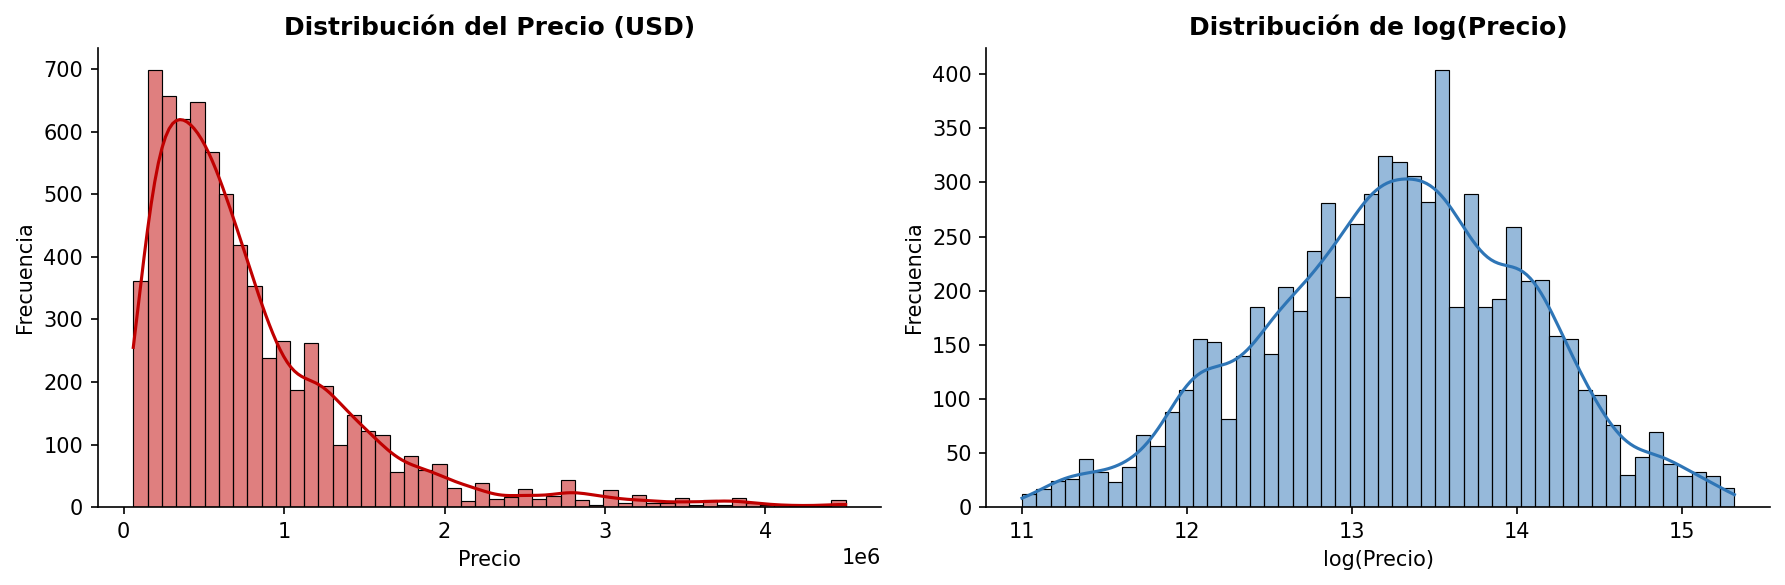

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma Precio Original
sns.histplot(df['Precio'], bins=50, color=RED, kde=True, ax=axes[0])
axes[0].set_title("Distribución del Precio (USD)")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Frecuencia")

# Histograma Precio Logarítmico
sns.histplot(df['precio_usd_log'], bins=50, color=BLUE, kde=True, ax=axes[1])
axes[1].set_title("Distribución de log(Precio)")
axes[1].set_xlabel("log(Precio)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## 2. Detección de Multicolinealidad
La multicolinealidad ocurre cuando dos o más variables predictoras están altamente correlacionadas. Esto infla la varianza de los coeficientes en Mínimos Cuadrados Ordinarios (MCO), justificando la necesidad de penalizaciones L1 y L2.

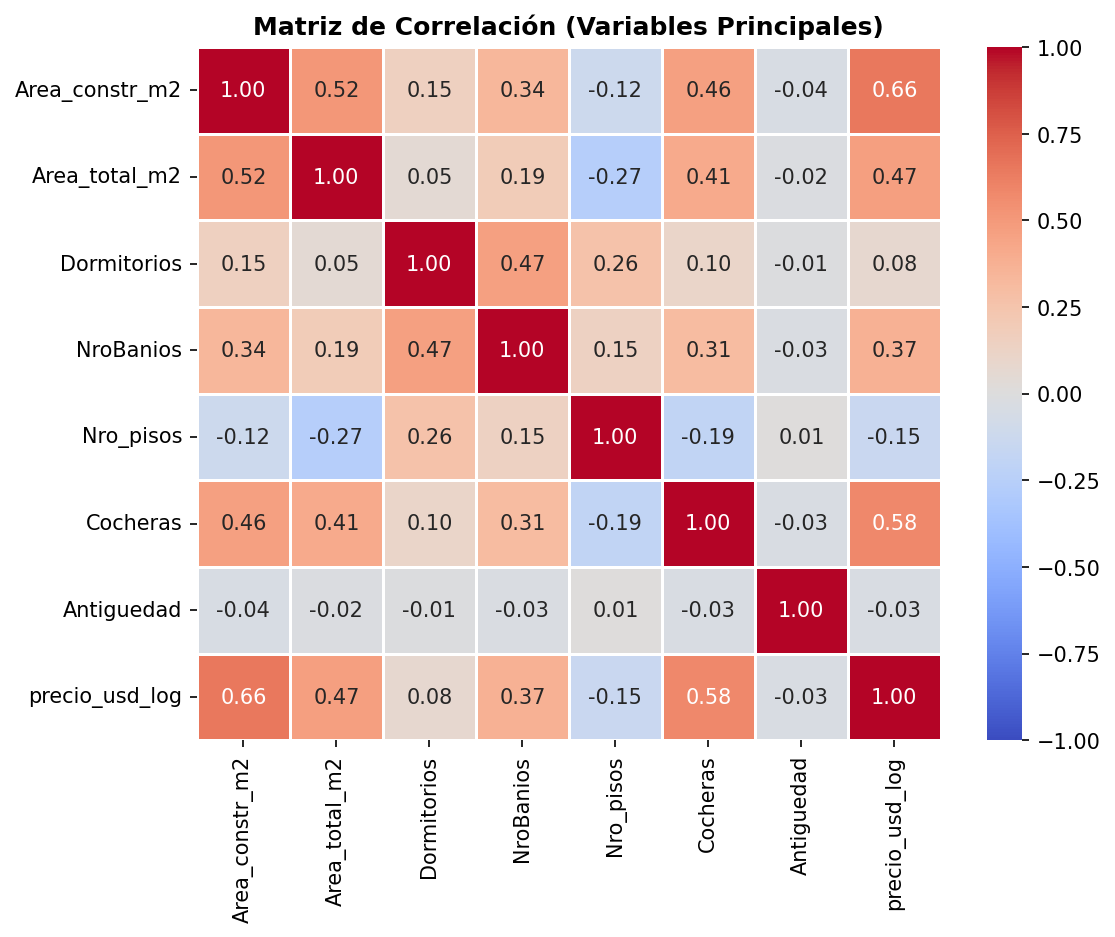

In [3]:
# Seleccionamos solo las variables numéricas continuas más relevantes para la correlación
cols_numericas = ['Area_constr_m2', 'Area_total_m2', 'Dormitorios', 
                  'NroBanios', 'Nro_pisos', 'Cocheras', 'Antiguedad', 'precio_usd_log']

matriz_corr = df[cols_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlación (Variables Principales)")
plt.show()

## 3. Relación entre Área Construida y Área Total
Observamos una altísima correlación entre el área construida y el área total. 
* **LASSO** tenderá a seleccionar solo una de estas variables y anular la otra (coeficiente = 0).
* **Elastic Net** tenderá a mantener ambas en el modelo y agrupar sus coeficientes.

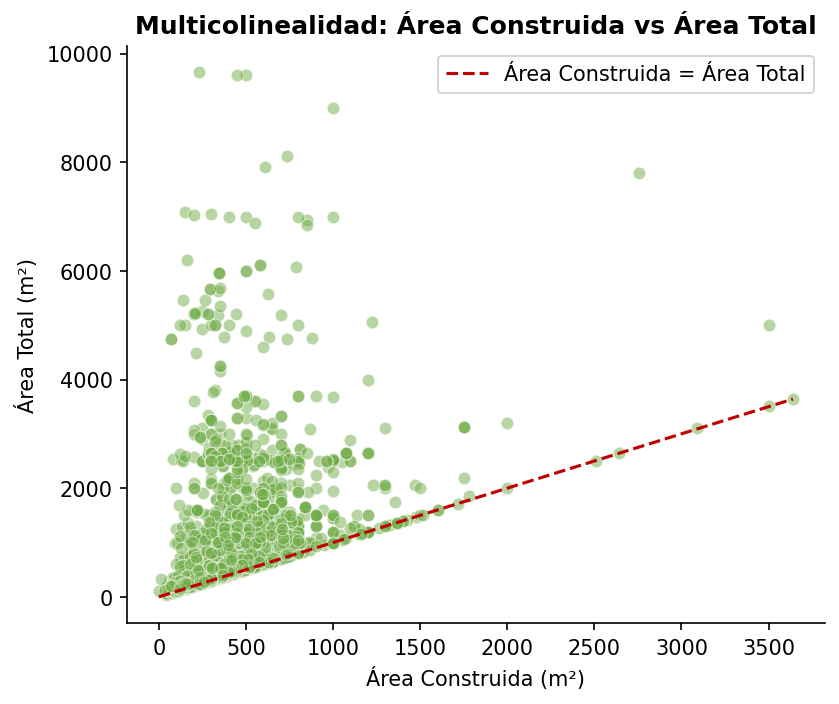

In [4]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='Area_constr_m2', y='Area_total_m2', data=df, alpha=0.5, color=GREEN)

# Línea de identidad (Área Construida = Área Total)
max_val = min(df['Area_constr_m2'].max(), df['Area_total_m2'].max())
plt.plot([0, max_val], [0, max_val], '--', color=RED, label='Área Construida = Área Total')

plt.title("Multicolinealidad: Área Construida vs Área Total")
plt.xlabel("Área Construida (m²)")
plt.ylabel("Área Total (m²)")
plt.legend()
plt.show()